In [814]:
import pymc as pm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import beta
from scipy.stats import pearsonr

#np.random.seed(42)
real_scores = np.array([72, 45, 38, 81, 55, 43, 78, 49, 68, 41])



In [815]:
with pm.Model() as apprentice_model:
    p_gifted = pm.Beta("p_gifted", alpha = 350, beta = 650)
    group = pm.Bernoulli("group", p=p_gifted, shape=1000)
    gifted_mu     = pm.Normal("gifted_mu",    mu=75, sigma=5)
    struggling_mu = pm.Normal("struggling_mu", mu=45, sigma=5)
    
    mu       = pm.math.switch(group, gifted_mu, struggling_mu)
    aptitude = pm.Normal("aptitude", mu=mu, sigma=10, shape=1000)
    wisdom_p = pm.Dirichlet("wisdom_p", a = np.array([100, 300, 100]))
    wisdom_tier = pm.Categorical("wisdom_tier", p=wisdom_p, shape=1000)
    wisdom_mus   = pm.Normal("wisdom_mus", mu=np.array([40, 60, 80]), sigma=3)
    wisdom_sigma = pm.HalfNormal("wisdom_sigma", sigma=8)
    wis_mu       = wisdom_mus[wisdom_tier]
    wisdom       = pm.Normal("wisdom", mu=wis_mu, sigma=wisdom_sigma, shape=1000)
    power_base      = pm.Normal("power_base", mu=20, sigma=5)

    aptitude_weight = pm.Beta("aptitude_weight", alpha=800, beta=300)
    wisdom_weight = pm.Beta("wisdom_weight", alpha = 200, beta = 600)
    power_sigma = pm.HalfNormal("power_sigma", sigma = 8)

    power_mu = power_base + aptitude_weight * aptitude + wisdom_weight * wisdom * 0.4
    power    = pm.Normal("power", mu=power_mu, sigma=power_sigma, shape=1000)

    samples = pm.sample_prior_predictive(draws=1)
    





x = np.linspace(0,1,100)



Sampling: [aptitude, aptitude_weight, gifted_mu, group, p_gifted, power, power_base, power_sigma, struggling_mu, wisdom, wisdom_mus, wisdom_p, wisdom_sigma, wisdom_tier, wisdom_weight]


In [816]:
wisdom_labels = {0: "Inept", 1: "Medium", 2: "Wise"}

groups        = samples.prior["group"].values[0, 0]
aptitude      = np.clip(samples.prior["aptitude"].values[0, 0], 0, 100)
wisdom_tier_v = samples.prior["wisdom_tier"].values[0, 0]
wisdom        = np.clip(samples.prior["wisdom"].values[0, 0], 0, 100)
power         = np.clip(samples.prior["power"].values[0, 0], 0, 100)



df = pd.DataFrame({
    "id":          [f"APP_{i:03d}" for i in range(1000)],
    "apt_type":    ["Gifted" if g else "Struggling" for g in groups],
    "aptitude":    np.round(aptitude, 1),
    "wisdom_tier": [wisdom_labels[w] for w in wisdom_tier_v],
    "wisdom":      np.round(wisdom, 1),
    "power":       np.round(power, 1)
})



df

,id,apt_type,aptitude,wisdom_tier,wisdom,power
0,APP_000,Struggling,38.0,Medium,63.3,51.7
1,APP_001,Struggling,70.7,Medium,63.4,74.4
2,APP_002,Gifted,78.9,Inept,44.1,74.9
3,APP_003,Struggling,50.4,Inept,44.8,57.0
4,APP_004,Struggling,47.2,Wise,79.0,72.2
...,...,...,...,...,...,...
995,APP_995,Struggling,70.2,Inept,44.5,76.5
996,APP_996,Gifted,86.6,Wise,79.5,77.5
997,APP_997,Gifted,75.1,Wise,79.4,79.6
998,APP_998,Struggling,27.0,Medium,62.9,38.2


In [817]:
df[["aptitude", "wisdom", "power"]].corr()



,aptitude,wisdom,power
aptitude,1.000000,-0.011543,0.833014
wisdom,-0.011543,1.000000,0.033312
power,0.833014,0.033312,1.000000


In [818]:
corr, p_value = pearsonr(df["aptitude"], df["power"])
print(f"Aptitude-Power correlation: {corr:.3f}, p-value: {p_value:.4f}")

corr, p_value = pearsonr(df["wisdom"], df["power"])
print(f"Wisdom-Power correlation: {corr:.3f}, p-value: {p_value:.4f}")

Aptitude-Power correlation: 0.833, p-value: 0.0000
Wisdom-Power correlation: 0.033, p-value: 0.2926


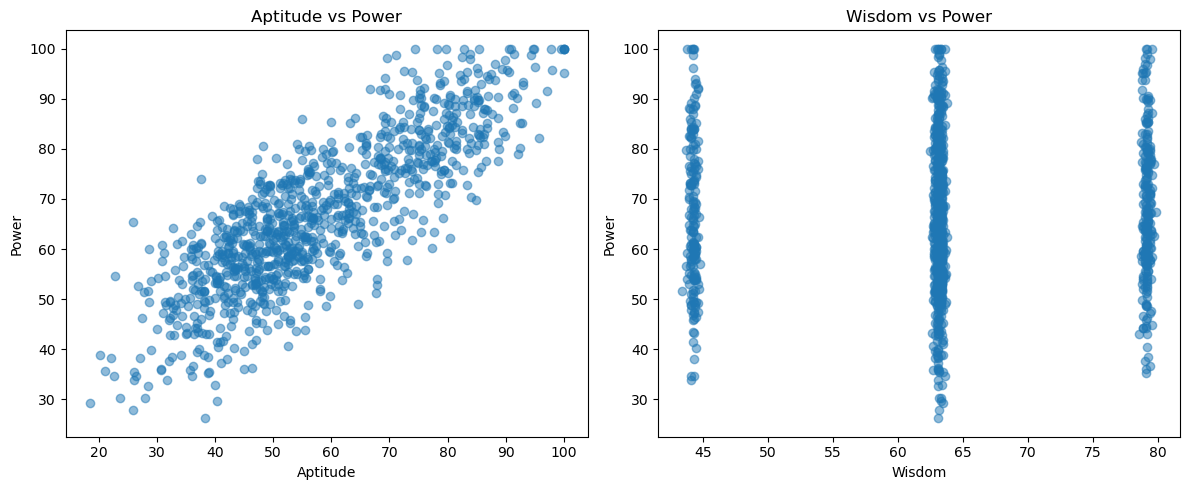

In [819]:

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.scatter(df["aptitude"], df["power"], alpha=0.5)
ax1.set_xlabel("Aptitude")
ax1.set_ylabel("Power")
ax1.set_title("Aptitude vs Power")

ax2.scatter(df["wisdom"], df["power"], alpha=0.5)
ax2.set_xlabel("Wisdom")
ax2.set_ylabel("Power")
ax2.set_title("Wisdom vs Power")

plt.tight_layout()
plt.show()

In [820]:
with pm.Model() as inference_model:
    p_gifted      = pm.Beta("p_gifted", alpha=3.5, beta=6.5)
    group         = pm.Bernoulli("group", p=p_gifted, shape=len(real_scores))
    
    gifted_mu     = pm.Normal("gifted_mu",    mu=75, sigma=5)
    struggling_mu = pm.Normal("struggling_mu", mu=45, sigma=5)
    
    mu       = pm.math.switch(group, gifted_mu, struggling_mu)
    aptitude = pm.Normal("aptitude", mu=mu, sigma=10, observed=real_scores)
    
    trace = pm.sample(1000, return_inferencedata=True)

Multiprocess sampling (4 chains in 4 jobs)
CompoundStep
>NUTS: [p_gifted, gifted_mu, struggling_mu]
>BinaryGibbsMetropolis: [group]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 1 seconds.


In [821]:
import arviz as az
az.summary(trace, var_names=["gifted_mu", "struggling_mu", "p_gifted"])

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
gifted_mu,74.424,3.782,67.333,81.680,0.058,0.056,4291.0,2698.0,1.0
struggling_mu,45.518,3.387,39.447,51.921,0.055,0.052,3856.0,2941.0,1.0
p_gifted,0.371,0.113,0.168,0.585,0.002,0.002,3847.0,2968.0,1.0


In [824]:
# Where does 68 sit relative to both group distributions?
from scipy.stats import norm

score = 62

gifted_mu_est    = trace.posterior["gifted_mu"].values.mean()
struggling_mu_est = trace.posterior["struggling_mu"].values.mean()

p_gifted_est = trace.posterior["p_gifted"].values.mean()
p_struggling_est = 1 - p_gifted_est

# Likelihood of this score under each group
like_gifted    = norm.pdf(score, gifted_mu_est,    10)
like_struggling = norm.pdf(score, struggling_mu_est, 10)

# Bayes theorem
unnorm_gifted    = like_gifted    * p_gifted_est
unnorm_struggling = like_struggling * p_struggling_est

total = unnorm_gifted + unnorm_struggling

print(f"Score: {score}")
print(f"P(Gifted):     {unnorm_gifted/total:.1%}")
print(f"P(Struggling): {unnorm_struggling/total:.1%}")

Score: 62
P(Gifted):     51.5%
P(Struggling): 48.5%
